# Konvolüsyon Sezgileri

Bu **`konvolüsyon işlemleri`** hakkında bazı sezgiler geliştirelim.

🎯 <b><u>Hedefler</u>:</b>
- **Konvolüsyon işlemlerini anlamak**
- **Görselleştirmek**
    - konvolüsyon kernellerini
    - görüntülere uygulanan bir konvolüsyon kernelinın etkilerini

<hr>

🖼 <b><u>Evrişimli Sinir Ağları, özellikle görüntüler üzerinde çalışmak için tasarlanmış Sinir Ağlarıdır</u></b>. 

- 🧮 Bu, **`konvolüsyon işlemleri`** sayesinde mümkün olmaktadır.

- 🔎 Bu özel matematiksel işlemler, bir giriş görüntüsüne bir **`filtre`** (yani kanal başına bir **`kernel`** seti) uygular ve bir **`çıktı temsili`** oluşturur. Evrişimli Sinir Ağları için bu aynı zamanda şöyle de adlandırılabilir:
    * bir **`"konvolüt temsil/özellik"`**,
    * veya bir **`"konvolüsyon"`**,
    * veya aynı zamanda bir **`"aktivasyon"`** (belirli bir katmanın aktivasyonuna karşılık geldiği için).

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/CNN/convolution.png" width="300">

---

❗️ <b><u>Açıklamalar</u></b> ❗️

* **Aynı kernelin (yani aynı ağırlıkların) görüntünün farklı alanlarına uygulandığını** anlamak önemlidir. 

* Bu, Derin Öğrenme modülünün ilk iki biriminde çalıştığımız Yoğun Sinir Ağlarından tamamen farklıdır:
    * `Yoğun/"Tam Bağlı" Sinir Ağlarında`, belirli bir nöronun her ağırlığı yalnızca bir giriş koordinatıyla ilişkilidir (görüntülerde bu bir piksele karşılık gelir).
    * `Konvolüsyon Sinir Ağlarında`, bir kernelin ağırlıkları yalnızca bir özellik girişine, yani bir piksele uygulanmaz, bunun yerine farklı piksellere "adım adım" uygulanır!

👉 Her kerneli (veya renkli görüntüler söz konusu olduğunda her filtreyi) görüntüyü gördüğünüz bir **`büyüteç`** olarak düşünebilirsiniz. Gözlerinize benzer şekilde, kerneller bir resimdeki her şeyi aynı anda yakalayamazlar, ancak ***analiz edilen resmin tamamını anlamak için resmin farklı kısımlarını tararlar***.

🎬 O halde `konvolüsyon işlemlerine` ve bunların `Evrişimli Sinir Ağlarındaki` etkisine daha yakından bakalım.

## (0) Veri Seti

Verileri indirelim.

In [1]:
!wget https://d32aokrjazspmn.cloudfront.net/materials/circles-and-triangles.zip
!unzip -qn circles-and-triangles.zip

--2026-05-31 19:08:31--  https://d32aokrjazspmn.cloudfront.net/materials/circles-and-triangles.zip
18.245.46.80, 18.245.46.114, 18.245.46.121, ...rjazspmn.cloudfront.net)... 
connected. to d32aokrjazspmn.cloudfront.net (d32aokrjazspmn.cloudfront.net)|18.245.46.80|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 186323 (182K) [application/zip]
Saving to: ‘circles-and-triangles.zip’

circles-and-triangl 100%[===================>] 181.96K  --.-KB/s    in 0.1s    

2026-05-31 19:08:31 (1.24 MB/s) - ‘circles-and-triangles.zip’ saved [186323/186323]



İlk olarak, verileri yüklemek için aşağıdaki `load_data` fonksiyonunu kullanalım.

* Fonksiyonda hiçbir şeyi değiştirmeyin!
* Çıktıların şekillerini veya türlerini değiştirme isteğinden kaçının! Bu, sonraki soruları etkileyecektir.

In [2]:
import os
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline

def load_data(path):
    nb_circles = 100
    nb_triangles = 100

    X, y = [], []

    for i in range(nb_circles):
        c_path = os.path.join(path, 'circles', f'circle_{i}.png')
        X.append(np.array(Image.open(c_path))[:, :, :1])
        y.append(0)

    for i in range(nb_triangles):
        t_path = os.path.join(path, 'triangles', f'triangle_{i}.png')
        X.append(np.array(Image.open(t_path))[:, :, :1])
        y.append(1)

    c = list(zip(X, y))
    np.random.shuffle(c)
    X, y = zip(*c)

    return np.array(X), np.array(y)

X, y = load_data("data")

❓ **Şekil hakkında soru** ❓

* Kaç tane görüntümüz var?
* Boyutları nelerdir? 
* Kanal sayısı hakkında yorum yapabilir misiniz?

In [3]:
X.shape

(200, 76, 78, 1)

<details>
    <summary><i>Kanal sayısı hakkında:</i></summary>
   
Aslında, bunu daha önce `MNIST meydan okumasu` sırasında konuşmuştuk.        
        
*  Bir pikselin "*siyahlık yoğunluğunu*" hesaplamak için sadece bir kanala ihtiyacımız var; 0 siyah piksel, 1 beyaz piksel karşılık gelir. Son boyut bir çeşit "Siyahtan beyaza kanal"a karşılık gelir. 
        
🎨 Renkli görüntüler için, son boyut `Kırmızı, Yeşil, Mavi (RGB)` için 3 olur

👉 Kırmızı, Yeşil ve Mavi yoğunluklarıyla oynamaktan keyif alın <a href="https://www.w3schools.com/colors/colors_rgb.asp">`buradan`</a>
        
        
</details>

❓ **Normalizasyon hakkında soru** ❓

Bu görüntülerin normalizasyona ihtiyacı var mı?

In [4]:
np.min(X), np.max(X)

(0, 255)

<details><summary>Çözüm</summary>
Evet. 255 değerlerini görüyoruz. X'i 255'e bölerek kolayca ölçeklendirebilirsiniz.
</details>

In [5]:
X = X/255

👀 `plt.imshow` ile bazı görüntülere bakalım ve ilgili etiketlerini gösterelim.

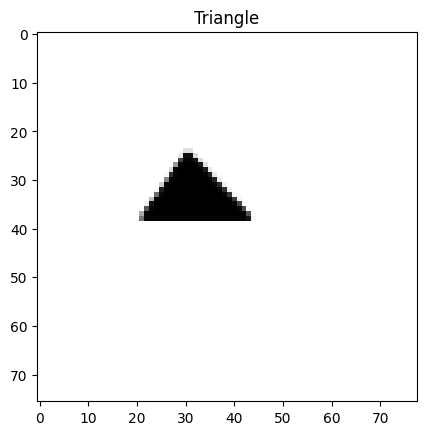

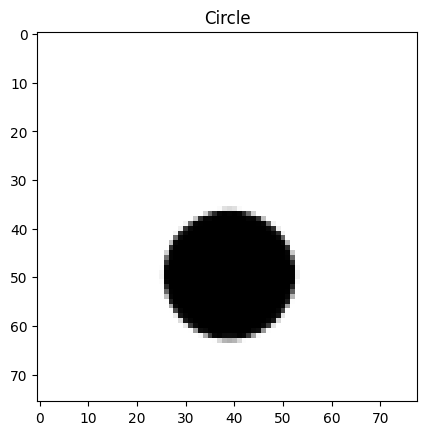

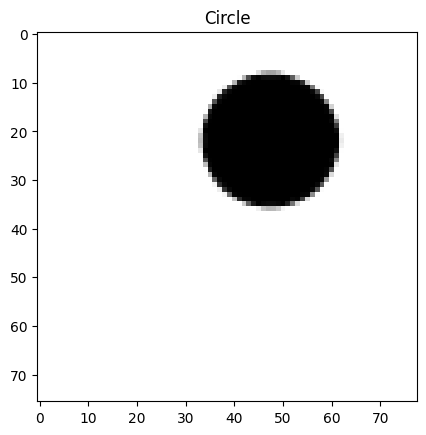

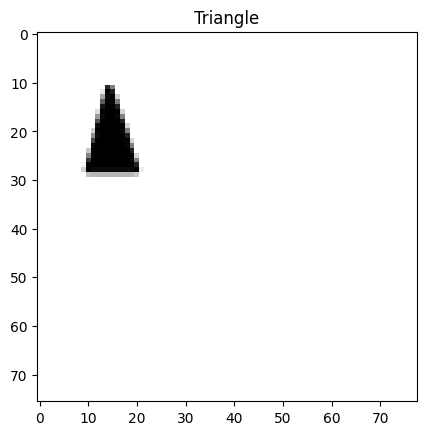

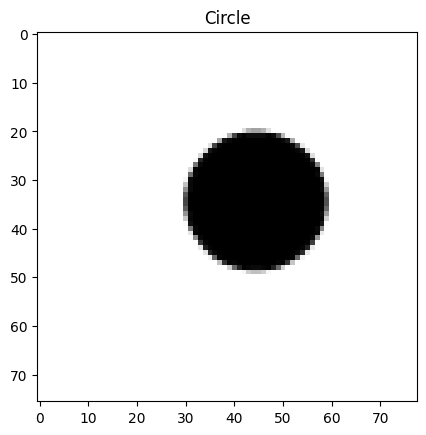

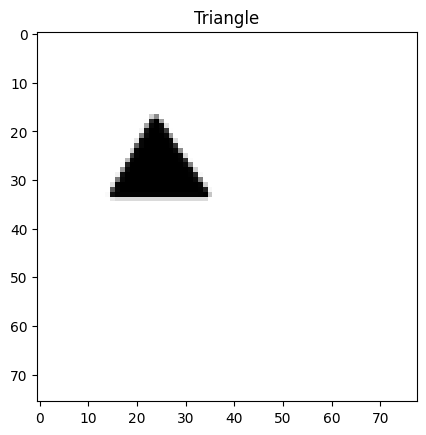

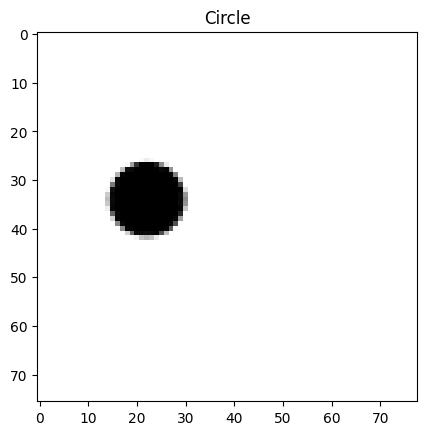

In [6]:
for iter_, (image, label) in enumerate(zip(X, y)):
    plt.imshow(image[:, :, 0], cmap='gray')
    plt.title('Triangle' if label == 1 else 'Circle')
    plt.show()

    if iter_ > 5:
        break

❓ **Soru: Kaç sınıfı tahmin edeceğiz** ❓

_Bu bilgi, Evrişimli Ağınızın son katmanını tasarlamanıza yardımcı olacaktır_

In [7]:
np.unique(y, return_counts=True)

(array([0, 1]), array([100, 100]))

## (1) Kerneller ve Konvolüsyonlar

🎁 Aşağıdaki **`compute_convolution`** fonksiyonu bir **konvolüsyon işlemi** gerçekleştirir $ \Leftrightarrow $ yani *bir kerneli bir görüntüye uygular*.

❓ **`compute_convolution` fonksiyonu hakkında soru** ❓

Çalıştırın ve bu fonksiyonun farklı adımlarını anlamaya çalışın.

In [8]:
def compute_convolution(input_image, kernel):
    # Parameters
    kernel = np.array(kernel)
    kernel_height, kernel_width = kernel.shape

    img = np.squeeze(input_image) # Removes dimensions of size 1
    img_height, img_width = img.shape

    output_image = []

    for x in range(img_height - kernel_height + 1):
        arr = []

        for y in range(img_width - kernel_width + 1):

            a = np.multiply(img[x: x + kernel_height, y: y + kernel_width],
                            kernel)
            arr.append(a.sum())

        output_image.append(arr)

    return output_image

❓ **`compute_convolution` fonksiyonu pratikte nasıl çalışır** ❓ 

1. Giriş veri setinden herhangi bir görüntüyü seçin
2. `identity_kernel`'i ona uygulayın
3. Hem giriş görüntüsünü hem de çıkış görüntüsünü görüntüleyin. 
4. Herhangi bir fark görüyor musunuz?

In [10]:
identity_kernel = [
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
]

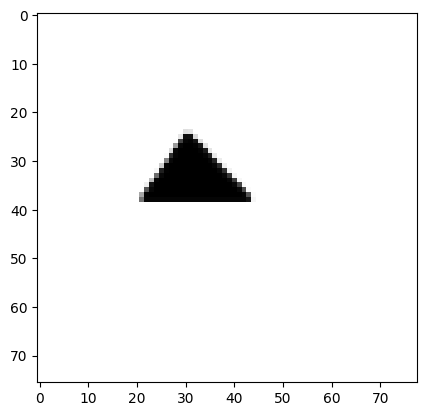

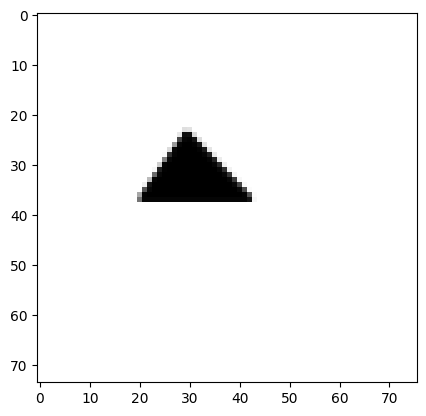

In [11]:
input_image = X[0]
kernel = identity_kernel

output_image = compute_convolution(input_image, kernel)

plt.imshow(np.squeeze(X[0]), cmap="gray")
plt.show()

plt.imshow(output_image, cmap="gray")
plt.show()

<details>
    <summary><i>Cevap</i></summary>
        
🧑🏻‍🏫 Önceki kernel **`identity_kernel`**'e karşılık gelir, yani ***çıktı girişe eşittir***... 
    
🕵🏻‍♂️ Temelde giriş görüntüsüne hiçbir şey yapmadı. Bunu iyice düşünürseniz, bu şaşırtıcı değil. Bu kernel ile, sadece ortada taranan piksel korundu ve bir ile çarpıldı, çevredeki pikseller sıfır ile çarpıldı.        
        
</details>

🎁 Bir kerneli bir giriş görüntüsüne uyguladıktan sonra çıktı görüntüsünü çizen **`plot_convolution`** fonksiyonunu kodladık.

In [12]:
def plot_convolution(img, kernel, activation=False):
    ''' The following printing function ease the visualization'''

    img = np.squeeze(img)
    output_img = compute_convolution(img, kernel)
    if activation:
        output_img = np.maximum(output_img, 0)

    plt.figure(figsize=(10, 5))

    ax1 = plt.subplot2grid((3,3),(0,0), rowspan=3)
    ax1.imshow(img, cmap='gray')
    ax1.title.set_text('Input image')

    ax2 = plt.subplot2grid((3,3),(1, 1))
    ax2.imshow(kernel, cmap='gray')
    ax2.title.set_text('Kernel')

    ax3 = plt.subplot2grid((3,3),(0, 2), rowspan=3)
    ax3.imshow(output_img, cmap='gray')
    ax3.title.set_text('Output image')

    for ax in [ax1, ax2, ax3]:
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)

    plt.show()

❓ **Soru** ❓ Aşağıdaki `kernel_1` ile `plot_convolution`'ı bir kez üçgen üzerinde ve bir kez daire üzerinde uygulayın.

In [13]:
kernel_1 = [
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
]

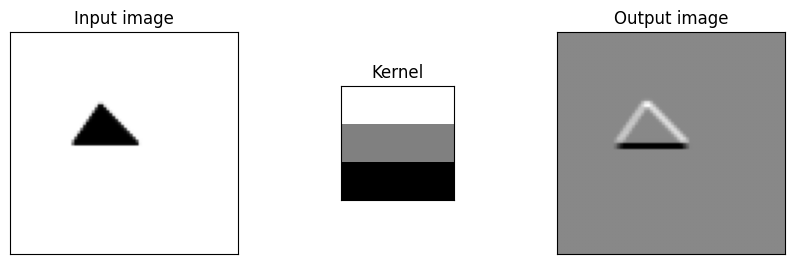

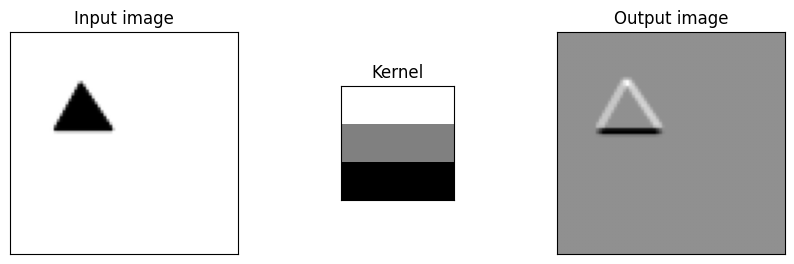

In [14]:
plot_convolution(X[0], kernel_1)
plot_convolution(X[5], kernel_1)

👆 Az önce ne olduğunu analiz edelim:

* Siyah pikseller düşük değerlere, beyaz pikseller yüksek değerlere karşılık gelir:
  * Giriş görüntüsü 0 (siyah olarak gösterilen) ile 1 (beyaz olarak gösterilen) arasında değişir.
  * Kerneller ve çıktı görüntüleri artık 0 ile 1 arasında değişmez, negatif bir sayıdan pozitif bir sayıya kadar değişir.
  * Görselleştirildiklerinde **siyah en düşük değeri** (bu durumda negatif bir değer) **ve beyaz en yüksek değeri** (bu durumda pozitif bir değer) temsil eder. Aradaki her şey grinin bir tonu olacaktır.
* Bir Sinir Ağında, doğrusallıkları kaldırmak için aktivasyon fonksiyonları kullandığımızı unutmayın. 
    * *Örneğin*, aktivasyon fonksiyonu `relu` olduğunda, bunun sadece negatif değerleri 0'a ayarlama anlamına geldiğini zaten biliyorsunuz.

---

❓ **Evrişimli Katmanda aktivasyon fonksiyonunun etkisi nedir ?** ❓

Önceki `plot_convolution` fonksiyonunu `activation` `True` olarak ayarlayarak tekrar çalıştırın (bu durumda aktivasyon fonksiyonu relu'dur).

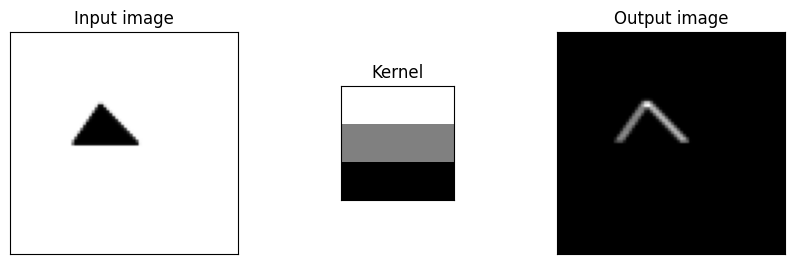

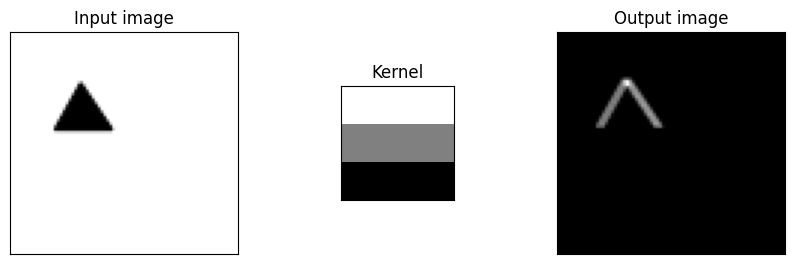

In [15]:
plot_convolution(X[0], kernel_1, activation=True)
plot_convolution(X[5], kernel_1, activation=True)

👆 Bu kernel aslında belirli bir yönde kenarları vurgulamaktadır.

❓ **Farklı kernellerle oynayın...** ❓

Tespit edebilecekleri farklı kenarları kontrol etmek için aşağıdaki kernelleri deneyin.

In [16]:
kernel_2 = [
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1],
]

kernel_3 = [
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
]

kernel_4 = [
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
]

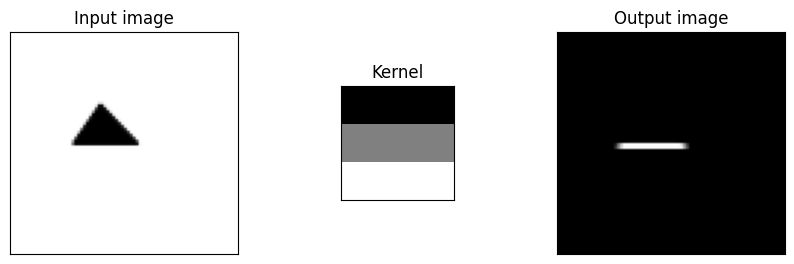

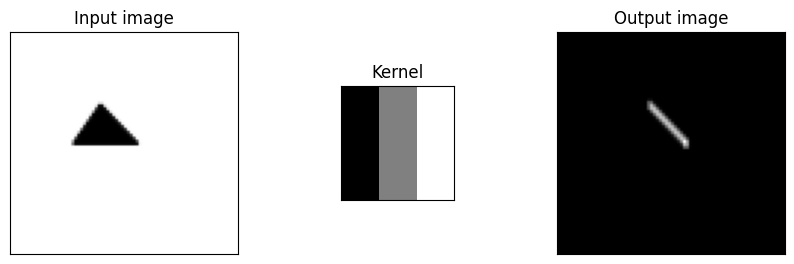

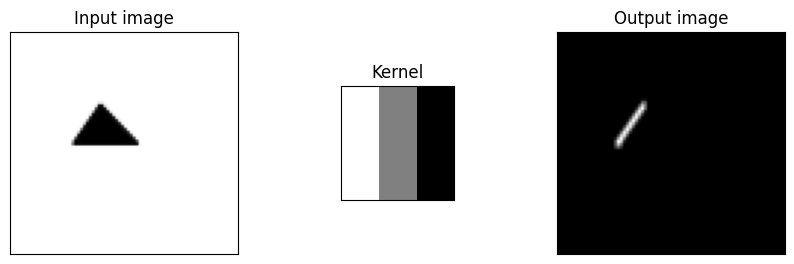

In [17]:
plot_convolution(X[0], kernel_2, activation=True)
plot_convolution(X[0], kernel_3, activation=True)
plot_convolution(X[0], kernel_4, activation=True)


❓ **Kernel boyutunun etkisi nedir** ❓

_kernel_big_'i deneyin.

In [18]:
kernel_big = np.array([
    np.ones((10,)),
    np.ones((10,)),
    np.ones((10,)),
    np.zeros((10,)),
    np.zeros((10,)),
    np.zeros((10,)),
    np.zeros((10,)),
    np.ones((10,))*-1,
    np.ones((10,))*-1,
    np.ones((10,))*-1,
])

kernel_big

array([[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
       [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1.]])

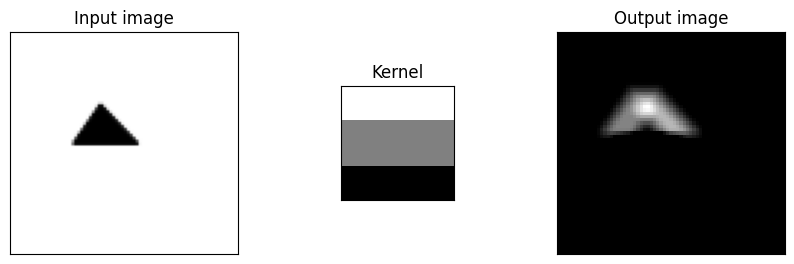

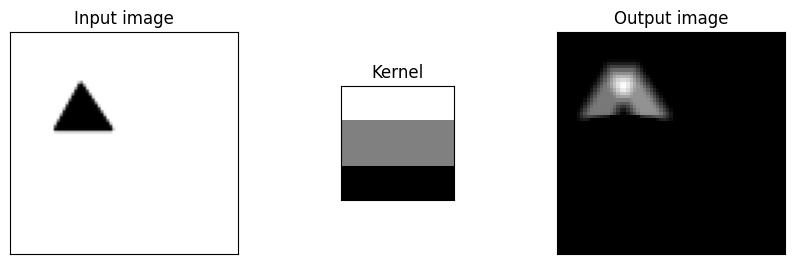

In [19]:
plot_convolution(X[0], kernel_big, activation=True)
plot_convolution(X[5], kernel_big, activation=True)


❓ **Başka bir kernel deneyin**  ❓

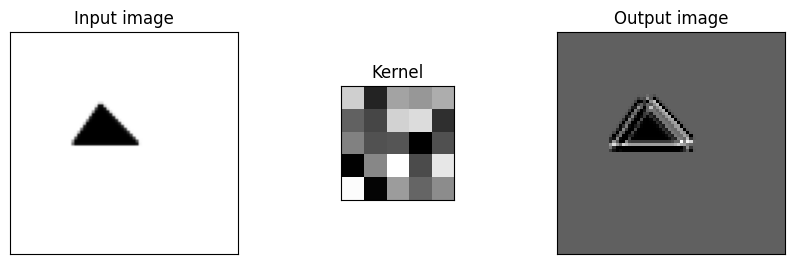

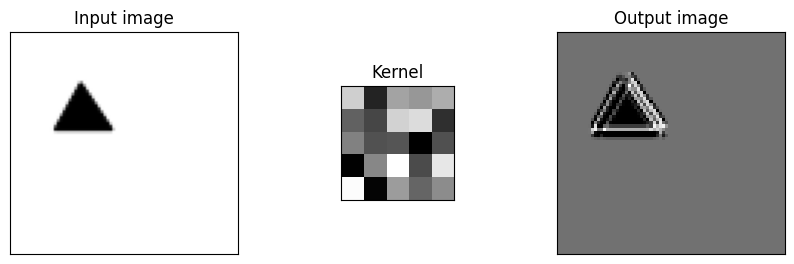

In [21]:
random_kernel = np.random.uniform(-10, 10, (5, 5))
plot_convolution(X[0], random_kernel, activation=True)
plot_convolution(X[5], random_kernel, activation=True)

Artık konvolüsyon işleminin bir görüntüye ne yaptığı konusunda fikriniz olduğuna göre, "gerçek" bir Evrişimli Sinir Ağı ile nasıl gittiğini görelim. ✅

## (2) Üçgen ve Daireleri Tespit Etmek için CNN Eğitmek

### (2.1) Mimari

❓ **Soru: CNN Tasarımı** ❓

Şu özelliklere sahip bir Evrişimli Ağ yazın:
- $ (4, 4) $ kernelleri ile 16 filtreli bir Evrişimli Katman.
- $ (3, 3) $ kernelleri ile 32 filtreli bir Evrişimli Katman.
- $ (3, 3) $ kernelleri ile 64 filtreli bir Evrişimli Katman.
- $ (2, 2) $ kernelleri ile 64 filtreli bir Evrişimli Katman.

ile birlikte:
- Her konvolüsyondan sonra bir Maksimum-Havuzlama Katmanı ($ (2, 2) $ havuz boyutu ile).
- Seçtiğiniz boyutta bir Gizli Yoğun Katman, makul olun:
    - düzleştirme kısmından sonra 
    - ama son katmandan önce

Ayrıca, modelinizi uygun parametrelerle derlediğinizden emin olun

In [22]:
from tensorflow.keras import Sequential, Input, layers

def initialize_model():

    model = Sequential()
    model.add(Input(shape=(76,78,1)))

    model.add(layers.Conv2D(16, (4, 4), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(64, (2, 2), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(units=10, activation='relu'))
    model.add(layers.Dense(units=1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                 optimizer='adam',
                 metrics =['accuracy'])
    

    return model

2026-05-31 20:05:55.162462: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 20:05:55.173865: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 20:05:55.250825: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 20:05:55.346181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-31 20:05:55.441281: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

### (2.2) Eğitim

❓ **Soru: CNN'i Eğitmek** ❓

* Modeli eğitin. *En az* %90 doğruluk elde etmelisiniz. 

    * Böyle yüksek bir puana ulaştığınızda, şüpheli gelebilir ve muhtemelen kendinize modelin aşırı öğrenme yapıp yapmadığını sorarsınız... ama bu meydan okuma için bunu görmezden gelelim 😏

In [23]:
model = initialize_model()
model.summary()

2026-05-31 20:06:38.851852: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-31 20:06:38.854113: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 75, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 36, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 34, 35, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,637 (178.27 KB)

 Trainable params: 45,637 (178.27 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from keras.callbacks import EarlyStopping

es = EarlyStopping(patience=5)

model = initialize_model()

history = model.fit(X, y,
                    validation_split=0.3,
                    batch_size=16,
                    epochs=50,
                    callbacks=[es],
                    verbose=1)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5143 - loss: 0.6943 - val_accuracy: 0.6667 - val_loss: 0.6817
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7500 - loss: 0.6679 - val_accuracy: 0.6667 - val_loss: 0.6487
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7429 - loss: 0.6058 - val_accuracy: 0.7500 - val_loss: 0.5470
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8857 - loss: 0.4533 - val_accuracy: 0.8500 - val_loss: 0.3680
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9357 - loss: 0.2339 - val_accuracy: 0.9500 - val_loss: 0.1666
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 842ms/step - accuracy: 0.9714 - loss: 0.1128 - val_accuracy: 0.9667 - val_loss: 0.1160
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ -7s -874770us/step - accuracy: 0.9857 - loss: 0.0546 - val_accuracy: 0.9667 - val_loss: 0.0428
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0237 - val_accuracy: 0.9833 - val_loss: 

🎁 Sizin için `plot_loss_accuracy` fonksiyonunu kodladık.

❓ **Soru: CNN yakınsar mı** ❓

_Ayrıca, herhangi bir aşırı öğrenme belirtisi görüyor musunuz?_

In [26]:
def plot_loss_accuracy(history, title=None):
    fig, ax = plt.subplots(1,2, figsize=(20,7))

    # --- LOSS ---

    ax[0].plot(history.history['loss'])
    ax[0].plot(history.history['val_loss'])
    ax[0].set_title('Model loss')
    ax[0].set_ylabel('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylim((0,3))
    ax[0].legend(['Train', 'Val'], loc='best')
    ax[0].grid(axis="x",linewidth=0.5)
    ax[0].grid(axis="y",linewidth=0.5)

    # --- ACCURACY

    ax[1].plot(history.history['accuracy'])
    ax[1].plot(history.history['val_accuracy'])
    ax[1].set_title('Model Accuracy')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].legend(['Train', 'Val'], loc='best')
    ax[1].set_ylim((0,1))
    ax[1].grid(axis="x",linewidth=0.5)
    ax[1].grid(axis="y",linewidth=0.5)

    if title:
        fig.suptitle(title)

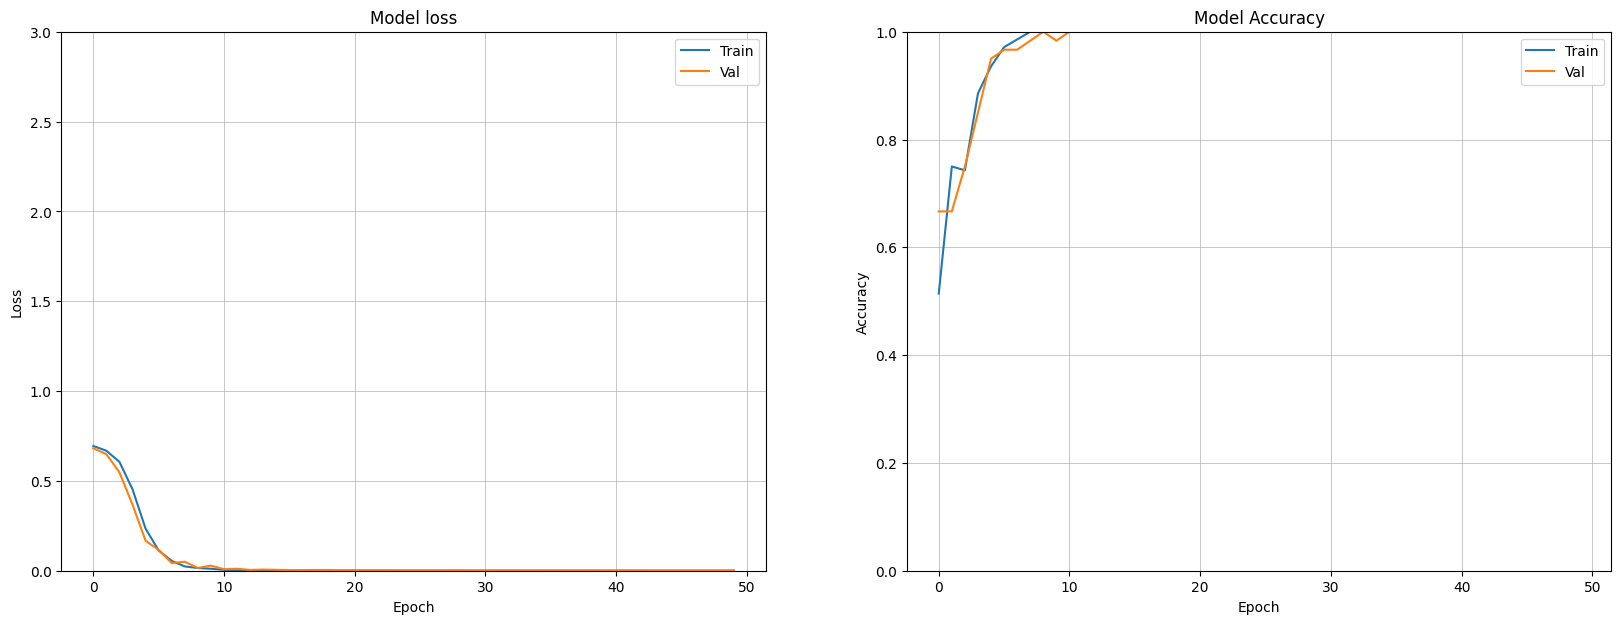

In [27]:
plot_loss_accuracy(history)


👏 Tebrikler! El yazısı rakamları sınıflandırmak için bir CNN çalıştırdıktan sonra, görüntüleri üçgen veya daire olarak sınıflandıracak başka bir CNN tasarlayabildiniz!

😏 Ancak, Bilgisayarlı Görü'nün açıkça bundan daha karmaşık olduğunu muhtemelen tahmin etmişsinizdir...

📆 `Meydan Okuma 3 - CIFAR10`'da, 10 kategori arasında görüntüleri sınıflandırmaya çalışacaksınız.

📚 Bu notebook'un son bölümü CNN'i daha derinlemesine anlamanıza yardımcı olacaktır. **Bir sonraki meydan okumaya geçmeden önce `(2.3) CNN'lerin Daha Derin Anlaşılması` bölümünü çok dikkatli bir şekilde okuyun!**

### 🎁 📚 (2.3) CNN'lerin Daha Derin Anlaşılması

👩🏻‍🏫 Herhangi bir Sıralı Sinir Ağı (Yoğun veya Evrişimli) için şunları yapabilirsiniz:
- katmanları ve dahil olan ağırlık/parametre sayısını görüntülemek için **`.summary()`**'yi yazdırın
- modelinizin farklı **`.layers`**'ına erişin

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 73, 75, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 35, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,913 (534.82 KB)

 Trainable params: 45,637 (178.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 91,276 (356.55 KB)

In [29]:
model.layers

[<Conv2D name=conv2d_4, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Conv2D name=conv2d_5, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Conv2D name=conv2d_6, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_7, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dense name=dense_3, built=True>]

🕵️‍♀️ Aşağıdaki tablo ile, daha önce oluşturduğunuz CNN'de yer alan farklı ağırlıklar, kerneller ve filtreler hakkında daha iyi bir genel bakışa sahip olacaksınız:

| katman_numarası | evrişimli_katman | kernel_sayısı | kanal_sayısı |
|-----------------|------------------|---------------|--------------|
| 0               | conv2D no 1      | 16            | 1            |
| 2               | conv2D no 2      | 32            | 16           |
| 4               | conv2D no 3      | 64            | 32           |
| 6               | conv2D no 4      | 64            | 64           |

#### (2.3.1) Kerneller

🧑🏻‍🏫 **Bir CNN eğittikten sonra her katman için tüm kernellerin değerlerini almak** mümkündür. 

👉 İlk olarak ilk evrişimli katmanın farklı parametrelerine (**`.weights`**) odaklanalım.

In [30]:
# Accessing the first convolutional layer of the CNN
first_convolutional_layer = model.layers[0]
first_convolutional_layer

<Conv2D name=conv2d_4, built=True>

In [31]:
# Weights of the first convolutional layer of the CNN - which was trained/optimized
first_convolutional_layer.weights[0].shape

TensorShape([4, 4, 1, 16])

👆 `TensorShape[4, 4, 1, 16]` şunları temsil eder:
- her kernelin ağırlıkları (boyut `4` $\times$ `4`)
- sadece `1` kanal vardı (tek S&B girişi)
- ve bu katmanda `16` farklı kernel uygulamaya karar verdik!

In [32]:
# Biases of the first convolutional layer of the CNN - which was trained/optimized
first_convolutional_layer.weights[1].shape

TensorShape([16])

👆 Bias'ları unutmayalım, çıktı görüntüsündeki her yeni kanal için bir tane!

In [33]:
# Notice that we have indeed 256 weights + 16 biases = 272 parameters for the first convolutional layer
4*4*1*16+16

272

> YOUR ANSWER HERE

In [34]:
# Accessing the second convolutional layer of the CNN
second_convolutional_layer = model.layers[2]
second_convolutional_layer

<Conv2D name=conv2d_5, built=True>

In [35]:
# Weights of the second convolutional layer of the CNN - which was trained/optimized
second_convolutional_layer.weights[0].shape

TensorShape([3, 3, 16, 32])

In [36]:
# Biases of the second convolutional layer of the CNN - which was trained/optimized
second_convolutional_layer.weights[1].shape

TensorShape([32])

In [37]:
# Notice that we have indeed 4608 weights + 32 biases = 4640 parameters for the third convolutional layer
3*3*16*32+32

4640

In [38]:
# Accessing the third convolutional layer of the CNN
third_convolutional_layer = model.layers[4]
third_convolutional_layer

<Conv2D name=conv2d_6, built=True>

In [39]:
# Weights of the third convolutional layer of the CNN - which was trained/optimized
third_convolutional_layer.weights[0].shape

TensorShape([3, 3, 32, 64])

In [40]:
# Biases of the third convolutional layer of the CNN - which was trained/optimized
third_convolutional_layer.weights[1].shape

TensorShape([64])

In [41]:
# Notice that we have indeed 18432 weights + 64 biases = 18496 parameters for the fourth convolutional layer
3*3*32*64+64

18496

In [42]:
# Accessing the fourth convolutional layer of the CNN
fourth_convolutional_layer = model.layers[6]
fourth_convolutional_layer

<Conv2D name=conv2d_7, built=True>

In [43]:
# Weights of the fourth convolutional layer of the CNN - which was trained/optimized
fourth_convolutional_layer.weights[0].shape

TensorShape([2, 2, 64, 64])

In [44]:
# Biases of the fourth convolutional layer of the CNN - which was trained/optimized
fourth_convolutional_layer.weights[1].shape

TensorShape([64])

In [45]:
# Notice that we have indeed 16384 weights + 64 biases = 16448 parameters for the fourth convolutional layer
(2*2*64+1)*64

16448

🚀 Artık her evrişimli katman için her kernelin eğitilmiş ağırlıklarına nasıl erişeceğimizi bildiğimize göre, bunların görüntülerin analizini nasıl etkilediğini araştıracağız.

* 🪄 **`plot_convolution(activation = True)`** kullanarak, ilk evrişimli katmandan 16 kerneli, aktivasyon çıktısıyla birlikte görüntüleyerek modelin bu katmanda görüntülerden ne öğrendiğini görelim.

------------------------- Effect of the kernel number 0 -------------------------


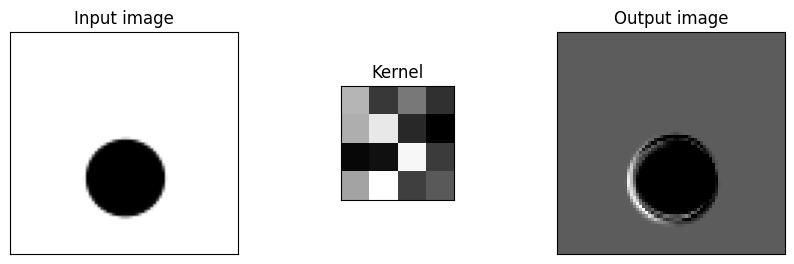

------------------------- Effect of the kernel number 1 -------------------------


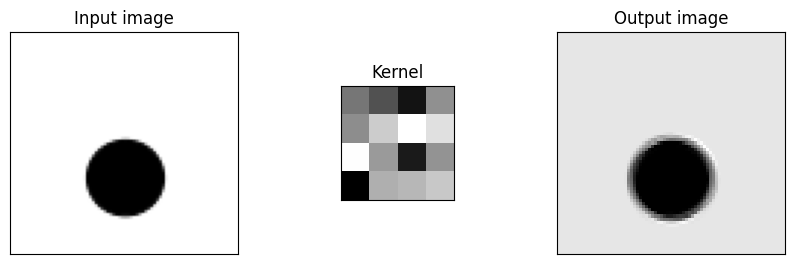

------------------------- Effect of the kernel number 2 -------------------------


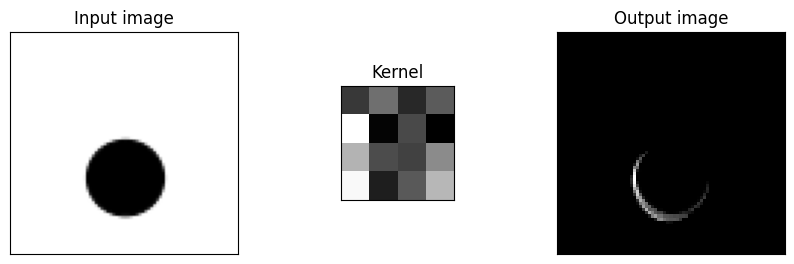

------------------------- Effect of the kernel number 3 -------------------------


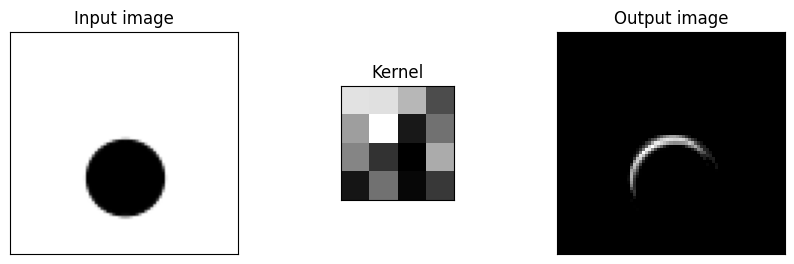

------------------------- Effect of the kernel number 4 -------------------------


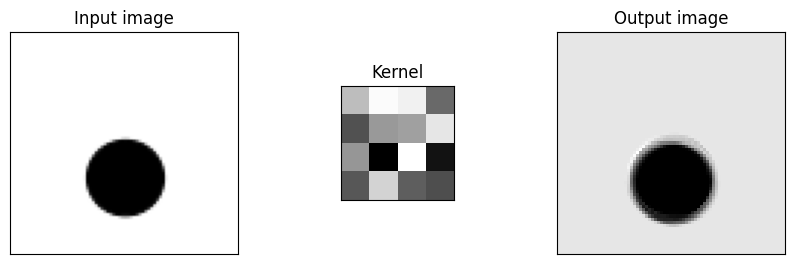

------------------------- Effect of the kernel number 5 -------------------------


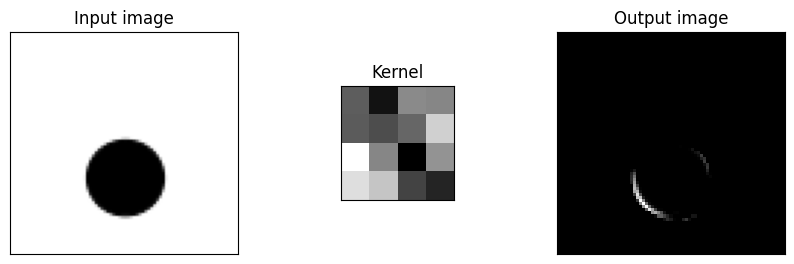

------------------------- Effect of the kernel number 6 -------------------------


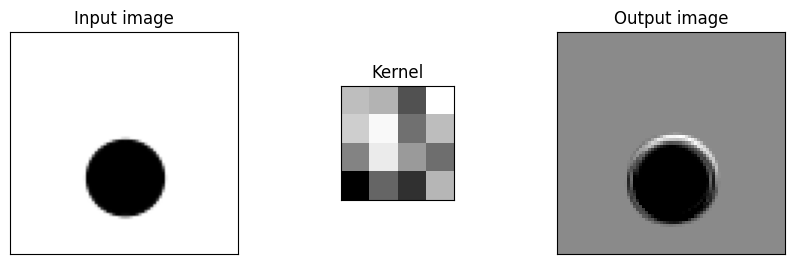

------------------------- Effect of the kernel number 7 -------------------------


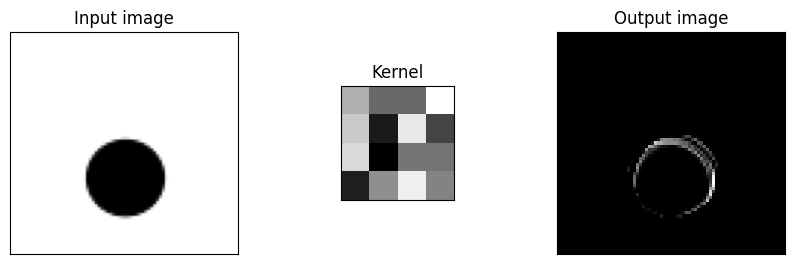

------------------------- Effect of the kernel number 8 -------------------------


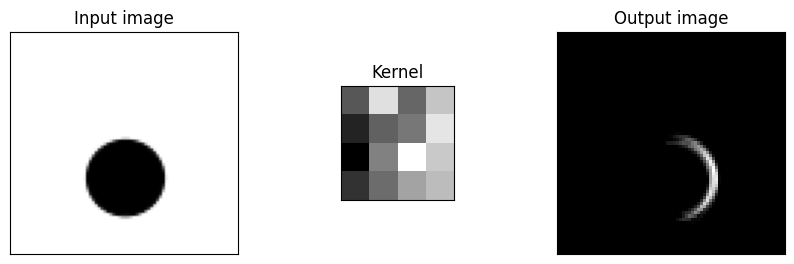

------------------------- Effect of the kernel number 9 -------------------------


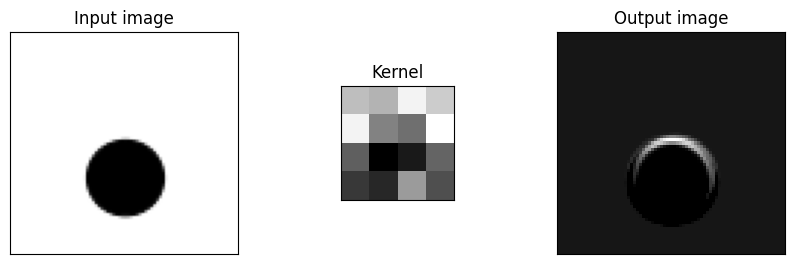

------------------------- Effect of the kernel number 10 -------------------------


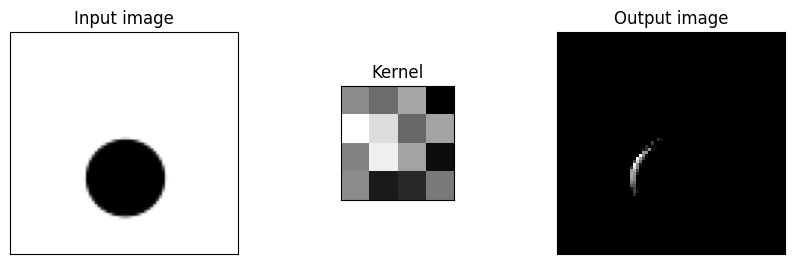

------------------------- Effect of the kernel number 11 -------------------------


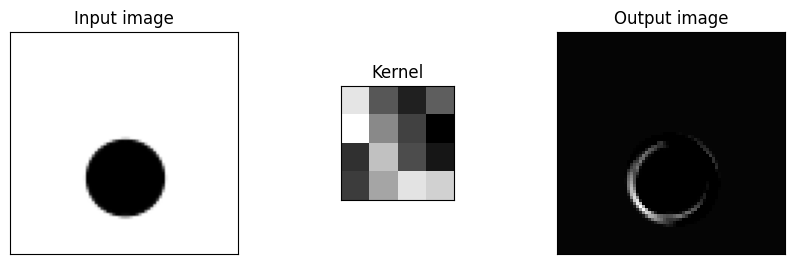

------------------------- Effect of the kernel number 12 -------------------------


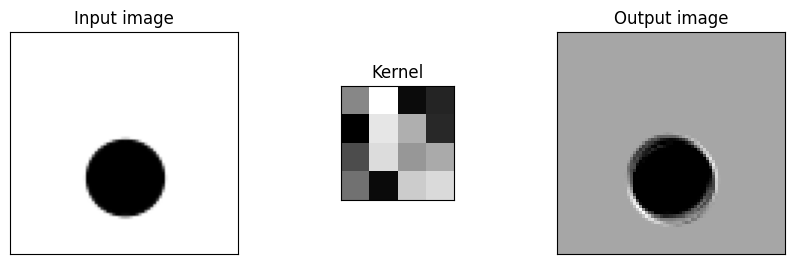

------------------------- Effect of the kernel number 13 -------------------------


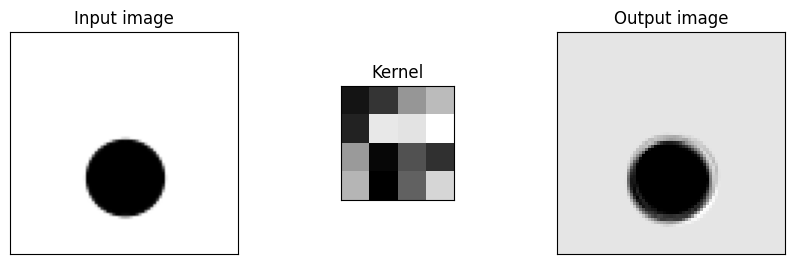

------------------------- Effect of the kernel number 14 -------------------------


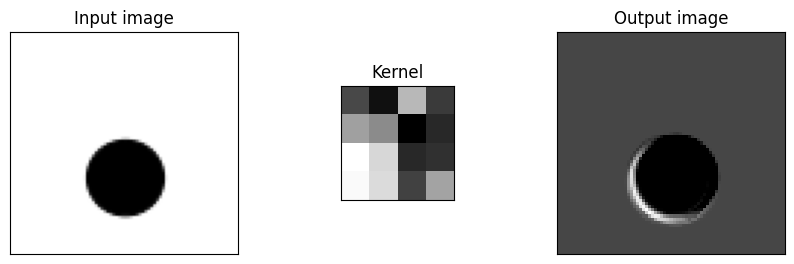

------------------------- Effect of the kernel number 15 -------------------------


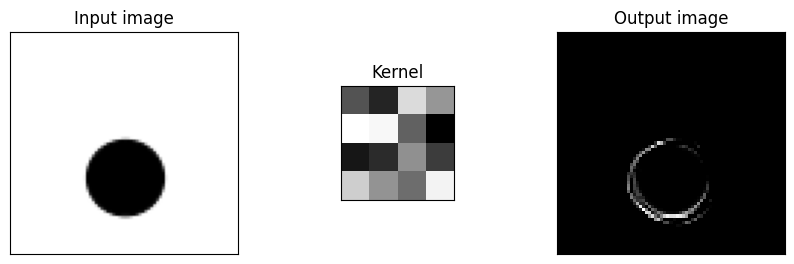

In [46]:
# First Convolutional Neural Network
layer_number = 0

# The input image has only 1 channel - Black&White picture
channel_number = 0

# Analyzing the impact of all the 16 kernels of the first convolutional layer
for k in np.arange(0, 16):
    print(f"------------------------- Effect of the kernel number {k} -------------------------")
    kernel = model.layers[layer_number].weights[0].numpy()[:, :, channel_number, k]
    plot_convolution(X[1], kernel, activation=True)

#### (2.3.2) Aktivasyonlar 🧨

Sadece **ilk evrişimli katmandan** sonra aktivasyona ("_çıktı görüntüsü_") bakıyorduk.

🤔 Peki **CNN'in her evrişimli katmanından sonra bir görüntünün aktivasyonunu görselleştirmek** istesek ne olur?

* 📚 Tensorflow/Keras'tan [**Functional API**](https://www.tensorflow.org/guide/keras/functional) kullanacağız.

* 💪 Bizimle kalın, bu notebook'un en zor kısmı ama aynı zamanda sonuncusu. Ve sadece odaklanıp okumanızı istiyoruz 😉

***Adım 0️⃣ : CNN özetinin Hatırlatması***

In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 73, 75, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 35, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,770 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,913 (534.82 KB)

 Trainable params: 45,637 (178.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 91,276 (356.55 KB)

***Adım 1️⃣: CNN'inizin 11 katmanının tüm çıktılarını listeleme***

In [48]:
layers_outputs = [layer.output for layer in model.layers]
layers_outputs

[<KerasTensor shape=(None, 73, 75, 16), dtype=float32, sparse=False, ragged=False, name=keras_tensor_68>,
 <KerasTensor shape=(None, 36, 37, 16), dtype=float32, sparse=False, ragged=False, name=keras_tensor_70>,
 <KerasTensor shape=(None, 34, 35, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_73>,
 <KerasTensor shape=(None, 17, 17, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_77>,
 <KerasTensor shape=(None, 15, 15, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_82>,
 <KerasTensor shape=(None, 7, 7, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_88>,
 <KerasTensor shape=(None, 6, 6, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_95>,
 <KerasTensor shape=(None, 3, 3, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_103>,
 <KerasTensor shape=(None, 576), dtype=float32, sparse=False, ragged=False, name=keras_tensor_112>,
 <KerasTensor shape=(None, 10), dtype=float32, sparse=Fal

***Adım 2️⃣ : Zaten eğitilmiş ağırlık ve bias'ları yeniden kullanarak 11 alt-model oluşturma***
- katman1
- katman1 $ \Rightarrow $ katman2
- katman1 $ \Rightarrow $ katman2 $ \Rightarrow $ katman3
- ... 

In [49]:
from keras import Model

activation_models = [Model(inputs=model.inputs, outputs=[output]) for output in layers_outputs]

***Adım 3️⃣ : Her alt-modelin çıktılarını hesaplama***

In [50]:
# You'll get some warnings, you can ignore them
activations = [m.predict(X) for m in activation_models]
len(activations)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


11

😎 PRO İPUCU:
* Tensorflow'da Python döngüleri/liste anlamalarından kaçınmak için birçok çıktılı tek bir model de oluşturabilirsiniz
* Adım 1️⃣ 2️⃣ 3️⃣ şu şekilde yapılabilir:

In [51]:
# You'll get some warnings, you can ignore them
layers_outputs = [layer.output for layer in model.layers] # same as above
activation_model = Model(inputs=model.inputs, outputs=layers_outputs) # model with many outputs !
activations = activation_model.predict(X) # 11 predictions at once!
[activation.shape for activation in activations]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step 


[(200, 73, 75, 16),
 (200, 36, 37, 16),
 (200, 34, 35, 32),
 (200, 17, 17, 32),
 (200, 15, 15, 64),
 (200, 7, 7, 64),
 (200, 6, 6, 64),
 (200, 3, 3, 64),
 (200, 576),
 (200, 10),
 (200, 1)]

#### (2.3.3) Final Gösteri 🥁

🔥 Artık aktivasyonlar hesaplandığına göre, veri setinden bir görüntüyü seçebilir ve her evrişimli katman boyunca farklı "aktivasyon görüntülerini" gözlemleyebiliriz! Başka bir deyişle, artık CNN'in her görüntü için ne gördüğünü gözlemlayebiliriz!

* 👇 Run the code down below and observe how a triangle was seen through the different convolutional layers.

In [ ]:
* 👇 Aşağıdaki kodu çalıştırın ve bir üçgenin farklı evrişimli katmanlar boyunca nasıl görüldüğünü gözlemleyin.

* 👇 Aşağıdaki kodu çalıştırın ve bir dairenin farklı evrişimli katmanlar boyunca nasıl görüldüğünü gözlemleyin.

--- Observing the effect of the convolutional layer number 0... ---

16 kernels were applied and here are all the activations of this Conv2D Layer:


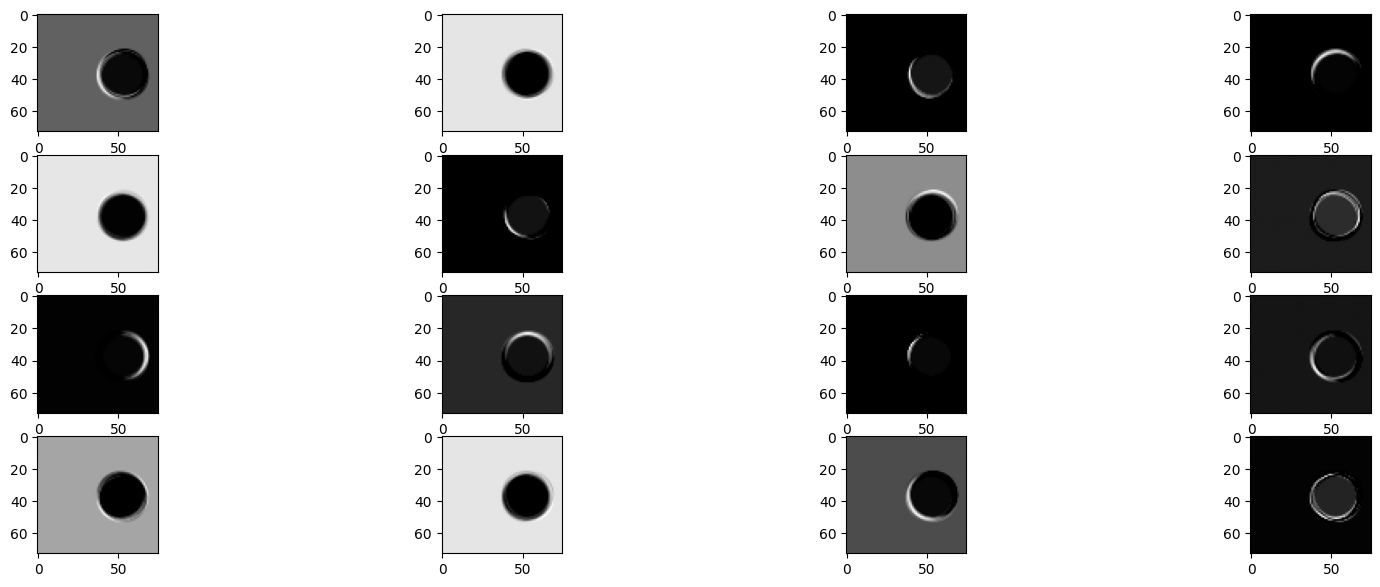

--- Observing the effect of the convolutional layer number 2... ---

32 kernels were applied and here are all the activations of this Conv2D Layer:


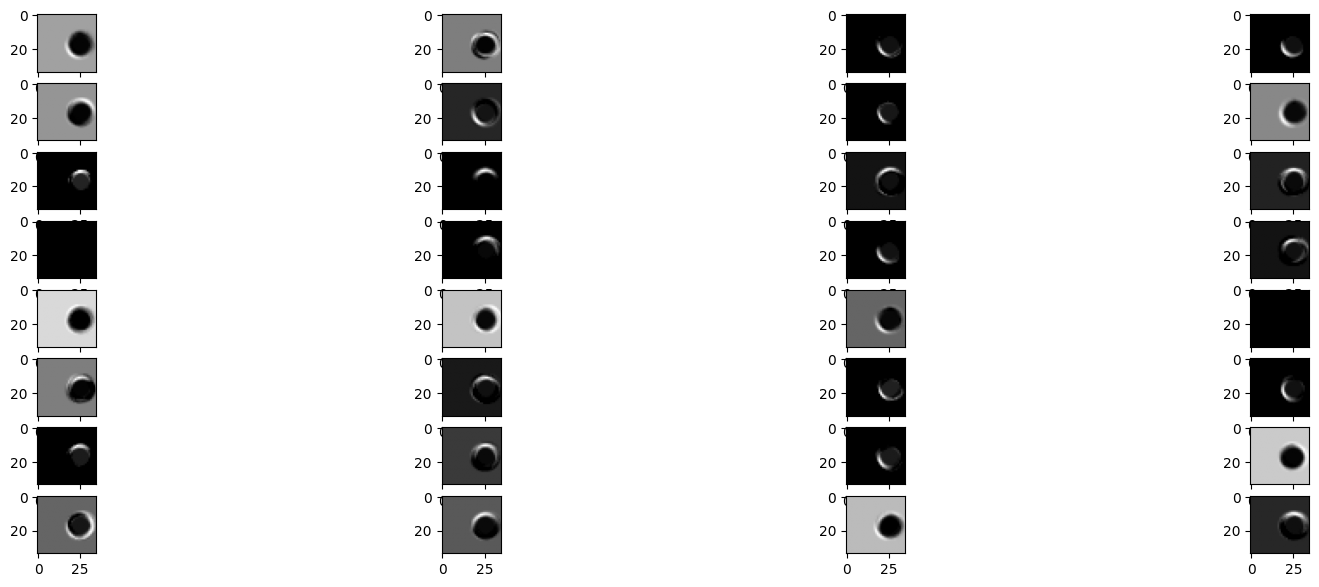

--- Observing the effect of the convolutional layer number 4... ---

64 kernels were applied and here are all the activations of this Conv2D Layer:


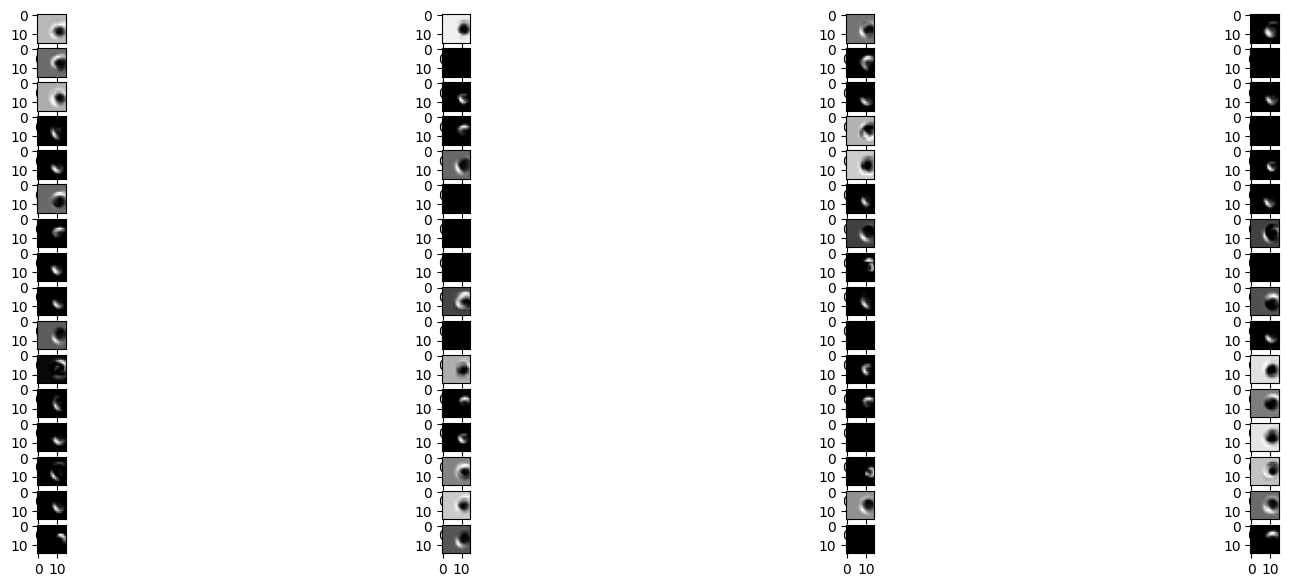

--- Observing the effect of the convolutional layer number 6... ---

64 kernels were applied and here are all the activations of this Conv2D Layer:


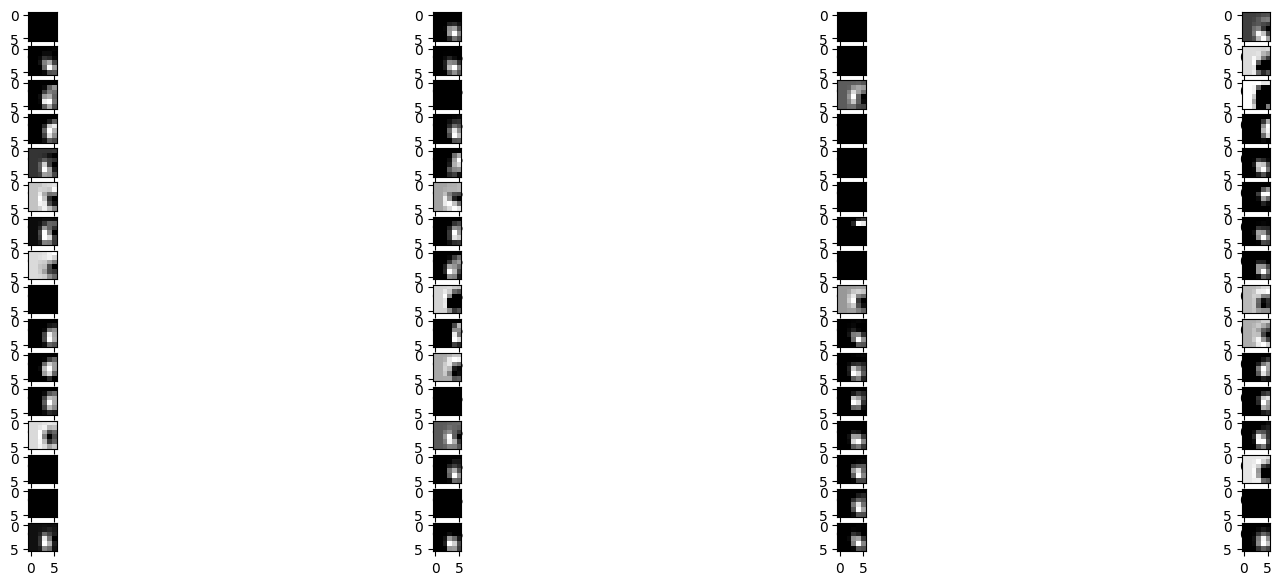

In [52]:
# Selecting a random triangle
image_number = np.random.choice(np.where(y == 0)[0])

for layer_number in [0,2,4,6]:

    print(f"--- Observing the effect of the convolutional layer number {layer_number}... ---")
    print("")

    temp_number_kernels = model.layers[layer_number].weights[0].shape[-1]
    print(f"{temp_number_kernels} kernels were applied and here are all the activations of this Conv2D Layer:")

    fig, axes = plt.subplots(int(temp_number_kernels/4),4, figsize=(20,7))


    for ax, kernel_number in zip(axes.flat,range(temp_number_kernels)):
        activation = activations[layer_number][image_number][:, :, kernel_number]
        ax.imshow(activation, cmap="gray")

    plt.show()


🧑🏻‍🏫 ***Notlar*** 🧑🏻‍🏫

1. Bir görüntünün bilgisinin Evrişimli Sinir Ağı boyunca nasıl **aktığını** fark edin.
2. Resmin giderek daha "soyut", giderek daha küçük "boyutlarda" olduğunu görmelisiniz

🕹 [Georgia Tech](https://www.gatech.edu/) araştırmacılarından [CNN Explainer](https://poloclub.github.io/cnn-explainer/) ile oynayın

🏁 **Tebrikler!**

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki meydan okumaya geçin!

## (Ek) Yardımcı Araçlar

* Aşağıdaki bölüm sadece üzerinde çalıştığınız üçgen ve daire veri setini oluşturmamıza yardımcı olan fonksiyonları sunar.

* Daha fazla prototip oluşturmak ve neler olup bittiğini daha iyi anlamak istemeniz durumunda notebook'un sonunda bırakıldılar. 

* Ancak ***Bilgisayarlı Görü'yü keşfettiğiniz bu ilk gün için, bu bölümü atlayın ve bir sonraki alıştırmaya geçin***, dilediğiniz zaman daha sonra geri dönebilirsiniz.

In [ ]:
def draw_triangle():
    dx = np.random.uniform(0.1, 0.3)
    dy = np.random.uniform(0.1, 0.3)
    noise_x = np.random.uniform(0.0, 0.1)
    noise_y = np.random.uniform(0.0, 0.1)

    x = np.random.uniform(0, 1-dx-noise_x)
    y = np.random.uniform(0, 1-dy)
    X = np.array([[x,y], [x+dx+noise_x,y], [x+dx/2, y+dy+noise_y]])

    t1 = plt.Polygon(X, color='black')
    plt.gca().add_patch(t1)

def draw_circle():
    r = np.random.uniform(0.1, 0.25)
    x = np.random.uniform(0+r, 1-r)
    y = np.random.uniform(0+r, 1-r)

    circle1 = plt.Circle((x, y), r, color='black')
    plt.gcf().gca().add_artist(circle1)

def create_image(form, path):
    plt.figure(figsize=(1, 1))
    if form == 'circle':
        draw_circle()
    elif form == 'triangle':
        draw_triangle()
    plt.axis('off')
    plt.savefig(path, dpi=80, bbox_inches='tight')
    plt.close()


def create_images(path):
    nb_circles = 100
    nb_triangles = 100

    for i in range(nb_circles):
        c_path = os.path.join(path, 'circles', f'circle_{i}.png')
        create_image('circle', c_path)

    for i in range(nb_triangles):
        t_path = os.path.join(path, 'triangles', f'triangle_{i}.png')
        create_image('triangle', t_path)